In [1]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt
from scipy.ndimage import uniform_filter1d
import soundfile as sf
import pywt

from transformers import Resampler, SpectralSubtractor, WaveletDenoiser
from config import SAMPLING_RATE, MAX_DURATION, MIN_DURATION

In [3]:
def plot_mel_with_segments(y, sr, segments, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)
    img = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax
    )
    for (s, e) in segments:
        ax.axvspan(s, e, color='white', alpha=0.3)

# Segmentador

En caso de usar ciclos respiratorios se debe tener una manera de identificar dichos ciclos. Esta es una versión improvisada de como podría ser, se usó para segmentar los audios propios y validar el funcionamiento de los modelos.

In [2]:
folder = './dataset/audios_propios'

X = []

for file in os.listdir(folder):
    if 'respiracion' in file:
        X.append(os.path.join(folder, file))

X

['./dataset/audios_propios\\respiracion1.ogg',
 './dataset/audios_propios\\respiracion10.ogg',
 './dataset/audios_propios\\respiracion11.ogg',
 './dataset/audios_propios\\respiracion12.ogg',
 './dataset/audios_propios\\respiracion13.ogg',
 './dataset/audios_propios\\respiracion14.ogg',
 './dataset/audios_propios\\respiracion15.ogg',
 './dataset/audios_propios\\respiracion2.ogg',
 './dataset/audios_propios\\respiracion3.ogg',
 './dataset/audios_propios\\respiracion4.ogg',
 './dataset/audios_propios\\respiracion5.ogg',
 './dataset/audios_propios\\respiracion6.ogg',
 './dataset/audios_propios\\respiracion7.ogg',
 './dataset/audios_propios\\respiracion8.ogg',
 './dataset/audios_propios\\respiracion9.ogg']

## Energy Based
El método probado es Energy Based, este es el método más simple y generalmente más usado.  
Estoy seguro de que debe haber otros mejores para audios de celular, este método es un poco sensible al ruido.

In [4]:
def filter(y, sr, lowcut=0, highcut=4_000, order=4): # bandpass o lowpass
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    if low == 0:
        b, a = butter(order, high, btype='low')
    else:
        b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, y)

def filter_and_resample(path, sr_target=SAMPLING_RATE, lowcut=0, highcut=4_000):
    y, sr = librosa.load(path, sr=None)
    y = filter(y, sr, lowcut=lowcut, highcut=highcut)
    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
    return y, sr_target

def spectral_subtract(y, sr, n_fft=1024, hop_length=512, win_length=1024, alpha=1.5):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag, phase = np.abs(S), np.angle(S)

    noise_mag = np.median(mag, axis=1, keepdims=True)

    mag_denoised = mag - alpha * noise_mag
    mag_denoised = np.maximum(mag_denoised, 1e-10)
    S_d = mag_denoised * np.exp(1j * phase)
    y_d = librosa.istft(S_d, hop_length=hop_length, win_length=win_length)
    return y_d, sr

def wavelet_denoise(signal, wavelet='db4', level=4, threshold_method='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # estimación del ruido
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [
        pywt.threshold(c, value=uthresh, mode=threshold_method)
        for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_thresh, wavelet)

def segmentar_energy_based(y, sr, percentile=50, min_event_duration=0.5, alpha=1.5):
    # Reducción de ruido
    y, sr= spectral_subtract(y, sr, alpha=alpha) # o wavelet_denoise(y, level=4, threshold_method='soft')

    # Calcular energía por frame
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    times = librosa.times_like(rms, sr=sr, hop_length=512)

    median = np.median(rms)
    mad = np.median(np.abs(rms - median))  # medida robusta de dispersión
    max_allowed = median + 5 * mad  # o 3–5 según sensibilidad
    rms_clipped = np.clip(rms, None, max_allowed)

    threshold = np.percentile(rms_clipped, percentile)
    active = rms > threshold

    segments = [] # inhalaciones o exhalaciones
    start = None
    for i, val in enumerate(active):
        if val and start is None:
            start = times[i]
        elif not val and start is not None:
            end = times[i]
            if end - start > min_event_duration:
                segments.append((start, end))
            start = None
    
    return segments

def detectar_gaps(segments, dur_audio, gap_threshold=3.0):
    """Detecta gaps sin segmentos."""
    gaps = []
    prev_end = 0
    for start, end in segments:
        if start - prev_end > gap_threshold:
            gaps.append((prev_end, start))
        prev_end = end
    if dur_audio - prev_end > gap_threshold:
        gaps.append((prev_end, dur_audio))
    return gaps

def unir_en_ciclos(segments):
    """Une pares de inhalación/exhalación en ciclos."""
    ciclos = []
    for i in range(0, len(segments), 2):
        if i + 1 < len(segments):
            ciclos.append((segments[i][0], segments[i + 1][1]))
        else:
            ciclos.append(segments[i])
    return ciclos

def refinar_ciclos_largos(ciclos, y, sr, max_cycle_duration=MAX_DURATION, percentile=50, min_event_duration=0.5, alpha=1.5):
    nuevos_ciclos = []

    for start, end in ciclos:
        dur = end - start
        if dur > max_cycle_duration:
            # Re-segmentar el ciclo largo
            y_segment = y[int(start*sr):int(end*sr)]
            sub_segments = segmentar_energy_based(y_segment, sr, percentile=percentile, min_event_duration=min_event_duration, alpha=alpha)
            # Ajustar tiempos al original
            sub_segments = [(s[0]+start, s[1]+start) for s in sub_segments]
            # Volver a unir en ciclos
            sub_ciclos = unir_en_ciclos(sub_segments)
            nuevos_ciclos.extend(sub_ciclos)
        else:
            nuevos_ciclos.append((start, end))

    return nuevos_ciclos

def procesar_audio(path, lowcut=1000, highcut=4000, percentile=50, min_event_duration=0.5, alpha=1.5, alpha_gap=1.5, gap_threshold=3.0, max_cycle_duration=MAX_DURATION, alpha_ciclos=1.5):
    y, sr = librosa.load(path, sr=None)
    y, sr = filter_and_resample(path, lowcut=lowcut, highcut=highcut) #bandpass, no hace falta el resampleo xq eso es parte del pipeline del modelo luego
    dur = len(y)/sr

    # Paso 1: segmentación inicial
    segments = segmentar_energy_based(y, sr, min_event_duration=min_event_duration, percentile=percentile, alpha=alpha)

    # Paso 2: detectar gaps
    gaps = detectar_gaps(segments, dur, gap_threshold=gap_threshold)

    # Paso 3: volver a segmentar los gaps
    for g_start, g_end in gaps:
        y_gap = y[int(g_start*sr):int(g_end*sr)]
        new_segments = segmentar_energy_based(y_gap, sr, min_event_duration=min_event_duration, percentile=percentile, alpha=alpha_gap)
        # Ajustar tiempos al original
        new_segments = [(s[0]+g_start, s[1]+g_start) for s in new_segments]
        segments.extend(new_segments)

    # Ordenar segmentos
    segments.sort(key=lambda x: x[0])

    # Paso 4: unir en ciclos
    ciclos = unir_en_ciclos(segments)

    # Paso 5: refinar ciclos largos
    ciclos = refinar_ciclos_largos(ciclos, y, sr, max_cycle_duration=max_cycle_duration,
                                    percentile=percentile, min_event_duration=min_event_duration, alpha=alpha_ciclos)

    return ciclos


El proceso anterior esta muy lejos de ser perfecto. Debería ser recursivo.

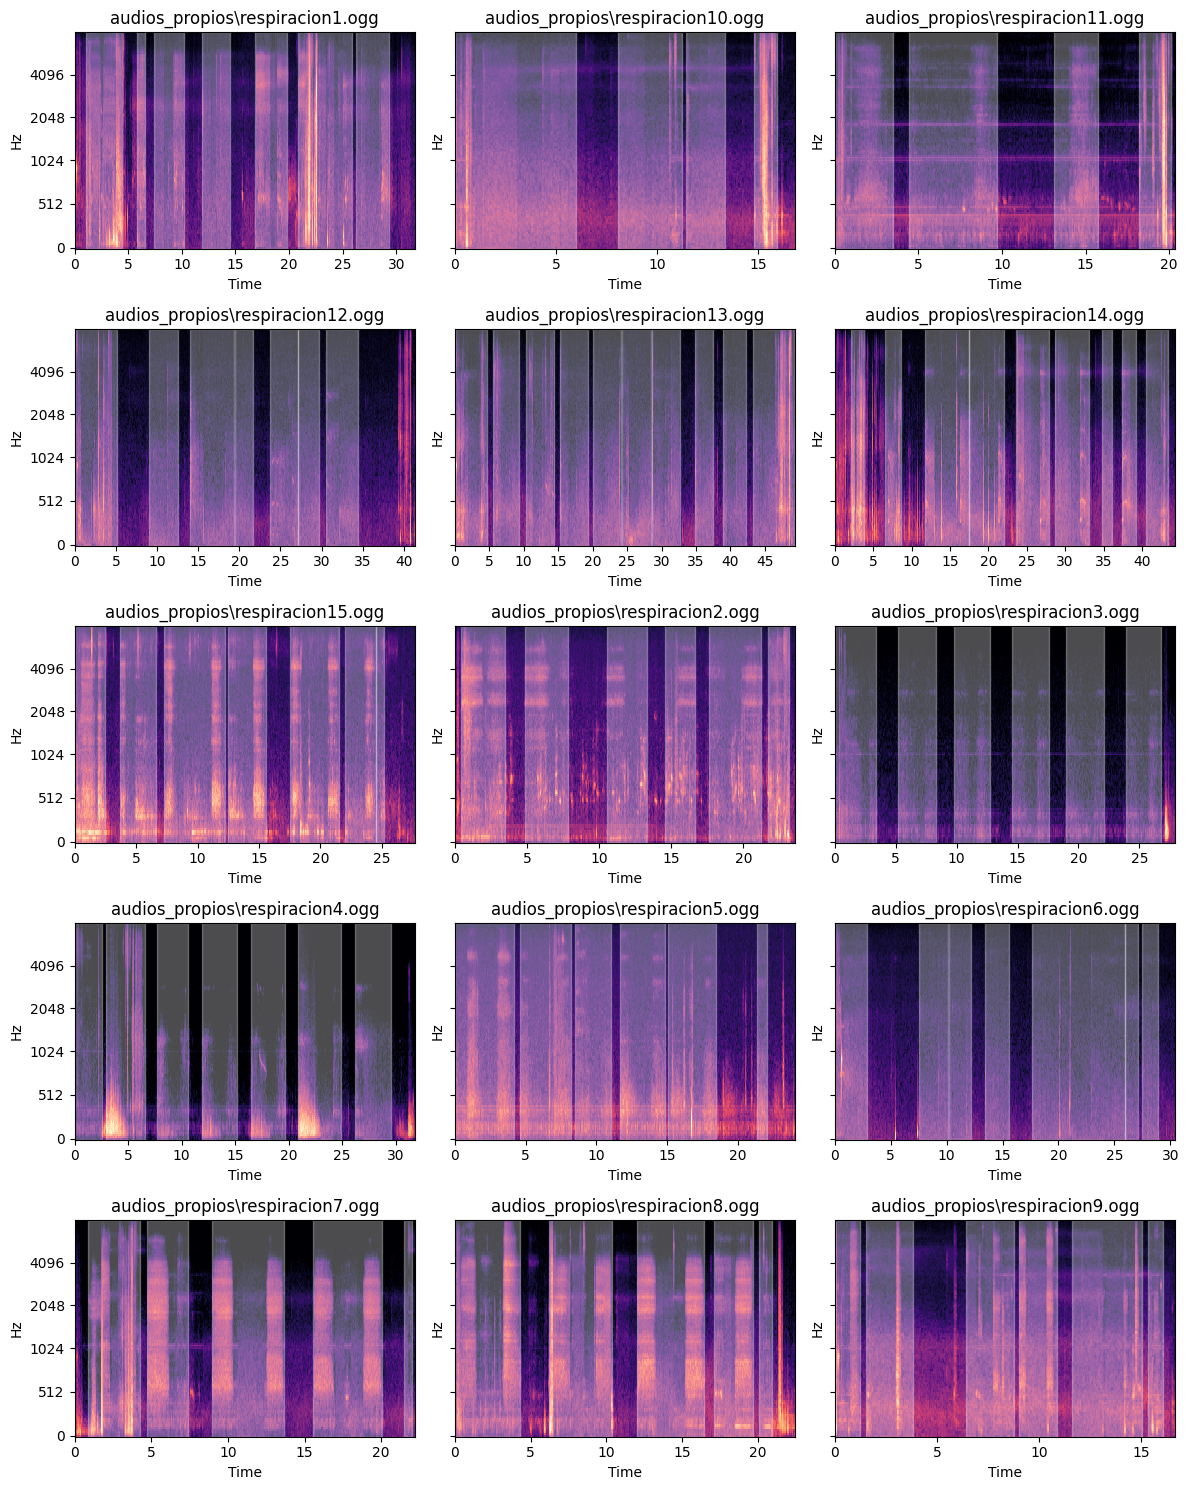

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(12, 15), sharey=True)

axes = axes.flatten()

for i, path in enumerate(X):
    y, sr = librosa.load(path, sr=SAMPLING_RATE)
    ciclos = procesar_audio(path, lowcut=1000, highcut=4000, percentile=50, min_event_duration=0.5, alpha=1.5,
                            alpha_gap=1.5, gap_threshold=2.0,
                            alpha_ciclos=2) #tambien podria agregar percentile de cliclos y gaps

    plot_mel_with_segments(y, sr, ciclos, ax=axes[i])
    axes[i].set_title(f"{path.split('/')[-1]}")

plt.tight_layout()
plt.show()

Guardamos los ciclos

In [12]:
output_folder = './data_procesada/ciclos_propios_eb'
os.makedirs(output_folder, exist_ok=True)

# guardar ciclos
for path in X:
    y, sr = librosa.load(path, sr=SAMPLING_RATE)
    ciclos = procesar_audio(path, lowcut=1000, highcut=4000, percentile=50, min_event_duration=0.5, alpha=1.5,
                            alpha_gap=1.5, gap_threshold=2.0,
                            alpha_ciclos=2)

    base_name = os.path.basename(path).replace('.ogg', '')
    for i, (start, end) in enumerate(ciclos):
        start_sample = int(start * sr)
        end_sample = int(end * sr)
        ciclo_audio = y[start_sample:end_sample]
        output_path = os.path.join(output_folder, f"{base_name}_ciclo{i+1}.wav")
        sf.write(output_path, ciclo_audio, sr)

Vamos a ver un mel

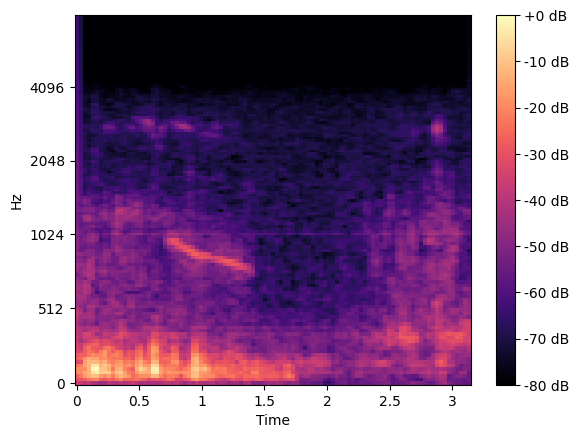

In [13]:
y, sr = filter_and_resample('./data_procesada/ciclos_propios_eb/respiracion4_ciclo5.wav')

# plot melspec
melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
melspec_db = librosa.power_to_db(melspec, ref=np.max)
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB");